### Analyze Visium H&E data

**Visium spots based purely on the tissue image**

This tutorial shows how to apply Squidpy for the analysis of Visium spatial transcriptomics data.

https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_visium_hne.html

#### Data

dataset portal <https://support.10xgenomics.com/spatial-gene-expression/datasets>



In [1]:
import numpy as np
import pandas as pd
import os, sys

import anndata as ad
import scanpy as sc
import squidpy as sq
import liana as li
from pathlib import Path

ROOT0 = Path("/home/flavio/uv/gwas/")
ROOT_SRC = ROOT0 / "src"

sys.path.append(str(ROOT_SRC))

from libs.Basic import create_dir, pdwritecsv, pdreadcsv
from libs.matplotlib_figure_style import *

import matplotlib.pyplot as plt

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

squidpy==1.8.4.dev25+g7a04f5884.d20260910


In [2]:
# load the pre-processed dataset
img = sq.datasets.visium_hne_image()

In [3]:
adata = sq.datasets.visium_hne_adata()

In [4]:
root0 = Path('/home/flavio/uv/squidpy/')
root_data = root0 / 'data'
root_figure = root0 / 'figures'
root_result = root0 / 'results'

os.listdir(root_figure)

['liana_cluster_dotplot.png', 'liana_spatial_LR.png']

In [5]:
filename = root_data / "visium_hne.h5ad"
adata.write_h5ad(filename)

### let’s visualize cluster annotation in spatial context with squidpy.pl.spatial_scatter().

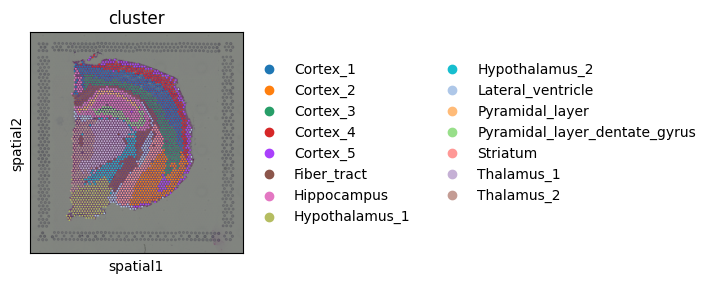

In [6]:
plt.rcParams['figure.figsize'] = (7,6)
# plt.rcParams['figure.dpi'] = 240

sq.pl.spatial_scatter(adata, color="cluster")

### Image feature

Visium datasets contain high-resolution images of the tissue that was used for the gene extraction. Using the function squidpy.im.calculate_image_features() you can calculate image features for each Visium spot and create a obs x features matrix in adata that can then be analyzed together with the obs x gene gene expression matrix.

By extracting image features we are aiming to get both similar and complementary information to the gene expression values. Similar information is for example present in the case of a tissue with two different cell types whose morphology is different. Such cell type information is then contained in both the gene expression values and the tissue image features.

Squidpy contains several feature extractors and a flexible pipeline of calculating features of different scales and sizes. There are several detailed examples of how to use squidpy.im.calculate_image_features(). Extract image features provides a good starting point for learning more.

### extract summary features at different crop sizes and scales

to allow the calculation of multi-scale features and segmentation features. For more information on the summary features, also refer to Extract [summary features](https://squidpy.readthedocs.io/en/latest/notebooks/examples/image/compute_summary_features.html).

In [7]:
# calculate features for different scales (higher value means more context)
for scale in [1.0, 2.0]:
    feature_name = f"features_summary_scale{scale}"
    print(">>>", feature_name)
    sq.im.calculate_image_features(
        adata,
        img.compute(),
        features="summary",
        key_added=feature_name,
        n_jobs=4,
        scale=scale,
    )


# combine features in one dataframe
adata.obsm["features"] = pd.concat(
    [adata.obsm[f] for f in adata.obsm.keys() if "features_summary" in f],
    axis="columns",
)
# make sure that we have no duplicated feature names in the combined table
adata.obsm["features"].columns = ad.utils.make_index_unique(
    adata.obsm["features"].columns
)

>>> features_summary_scale1.0


  0%|          | 0/2688 [00:00<?, ?/s]

>>> features_summary_scale2.0


  0%|          | 0/2688 [00:00<?, ?/s]

In [8]:
for i, key in enumerate(adata.obsm.keys()):
    print(i, key)

0 X_pca
1 X_umap
2 spatial
3 features_summary_scale1.0
4 features_summary_scale2.0
5 features


### extracted image features to compute a new cluster annotation

We can use the extracted image features to compute a new cluster annotation. This could be useful to gain insights in similarities across spots based on image morphology.


#### "features_cluster" are the "leinden" regions, what do they represent?

In that tutorial, `features_cluster` is a clustering of the **Visium spots based purely on the tissue image**, not on gene expression.

What's going on:

- `adata.obsm["features"]` comes from `sq.im.calculate_image_features(...)`. For each spot, Squidpy crops the H&E (or fluorescence) image around the spot's coordinates and computes numeric descriptors of that crop. The columns are prefixed by feature type: `summary_*`, `histogram_*`, `texture_*`, `segmentation_*`.
- `like="summary"` keeps only the summary-statistics features — per channel, things like mean, standard deviation, and quantiles of pixel intensity in the crop. So each spot is represented by a small vector describing how dark/light, how variable, and how colored its local patch of tissue looks.
- `cluster_features` then does the standard scanpy pipeline (scale → PCA → kNN graph → Leiden) on that matrix, treating spots as observations and image statistics as "genes".

So each Leiden label ("0", "1", "2", …) is an arbitrary integer identifying a group of spots whose local histology looks alike in terms of staining intensity and contrast — e.g. densely packed, darkly stained nuclei-rich regions vs. pale, sparse white matter vs. background/edge spots. The labels carry no biological name and no spatial constraint; spots in the same cluster can be scattered across the section.

The point of the tutorial is the comparison with `adata.obs["cluster"]` (the expression-derived, anatomically annotated clusters): plotting both side by side shows how much of the anatomy is recoverable from image appearance alone. You typically see partial correspondence — large-scale structures like cortex vs. white matter vs. hippocampus separate reasonably well, while finer expression-defined subregions collapse or split differently. Adding `texture` or `segmentation` features (nuclei counts, cell density) usually improves that agreement.

In [9]:
# helper function returning a clustering
def cluster_features(features: pd.DataFrame, like=None) -> pd.Series:
    """
    Calculate leiden clustering of features.
    Specify filter of features using `like`.
    """
    # filter features
    if like is not None:
        features = features.filter(like=like)
    # create temporary adata to calculate the clustering
    adata = ad.AnnData(features)
    # important - feature values are not scaled, so need to scale them before PCA
    sc.pp.scale(adata)
    # calculate leiden clustering
    sc.pp.pca(adata, n_comps=min(10, features.shape[1] - 1))
    sc.pp.neighbors(adata)
    sc.tl.leiden(adata)

    return adata.obs["leiden"]


In [10]:
# calculate feature clusters
adata.obs["features_cluster"] = cluster_features(adata.obsm["features"], like="summary")

/tmp/ipykernel_254612/3756014547.py:17: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.


In [11]:
for i, key in enumerate(adata.obsm.keys()):
    print(i, key)

0 X_pca
1 X_umap
2 spatial
3 features_summary_scale1.0
4 features_summary_scale2.0
5 features


In [12]:
dfc = adata.obs['cluster']
print(type(dfc), dfc.shape)
dfc.head(6)

<class 'pandas.core.series.Series'> (2688,)


AAACAAGTATCTCCCA-1          Cortex_2
AAACAATCTACTAGCA-1          Cortex_5
AAACACCAATAACTGC-1        Thalamus_2
AAACAGAGCGACTCCT-1          Cortex_5
AAACCGGGTAGGTACC-1        Thalamus_2
AAACCGTTCGTCCAGG-1    Hypothalamus_2
Name: cluster, dtype: category
Categories (15, object): ['Cortex_1', 'Cortex_2', 'Cortex_3', 'Cortex_4', ..., 'Pyramidal_layer_dentate_gyrus', 'Striatum', 'Thalamus_1', 'Thalamus_2']

### There are 257 clusters for Cortex 2

In [13]:
df2 = dfc[dfc=='Cortex_2']
print(df2.shape)
df2.head(3)

(257,)


AAACAAGTATCTCCCA-1    Cortex_2
AAATAGGGTGCTATTG-1    Cortex_2
AACACACGCTCGCCGC-1    Cortex_2
Name: cluster, dtype: category
Categories (15, object): ['Cortex_1', 'Cortex_2', 'Cortex_3', 'Cortex_4', ..., 'Pyramidal_layer_dentate_gyrus', 'Striatum', 'Thalamus_1', 'Thalamus_2']

In [14]:
adata.obsm.__dict__

{'_axis': 0,
 '_parent': AnnData object with n_obs × n_vars = 2688 × 18078
     obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'features_cluster'
     var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
     obsm: 'X_pca', 'X_umap', 'spatial', 'features_summary_scale1.0', 'features_summary_scale2.0', 'features'
     varm: 'PCs'
     obsp: 'connectivities', 'distance

In [15]:
df = adata.X
print(df.shape)
df

(2688, 18078)


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 15411927 stored elements and shape (2688, 18078)>

Plotting PCA for 'n_genes_by_counts' with dimensions (0, 1)
Plotting PCA for 'log1p_n_genes_by_counts' with dimensions (2, 3)
Plotting PCA for 'total_counts' with dimensions (0, 1)
Plotting PCA for 'log1p_total_counts' with dimensions (2, 3)


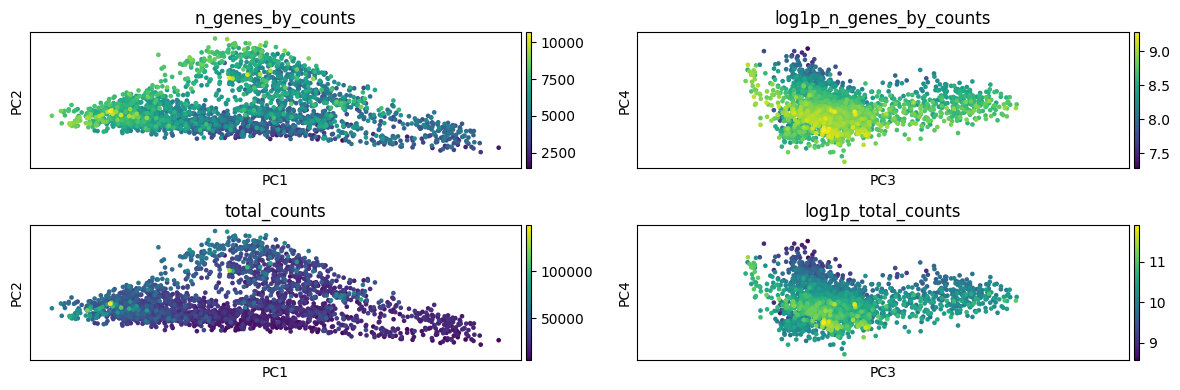

In [16]:
# obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'features_cluster'
# var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     
fig, axes = plt.subplots(2, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, color, dimensions in zip(axes.flat, ["n_genes_by_counts", "log1p_n_genes_by_counts", "total_counts", "log1p_total_counts"], [(0, 1), (2, 3), (0, 1), (2, 3)]):
    sc.pl.pca(adata, color=color, dimensions=dimensions, ax=ax, show=False)
    print(f"Plotting PCA for '{color}' with dimensions {dimensions}")

plt.tight_layout()

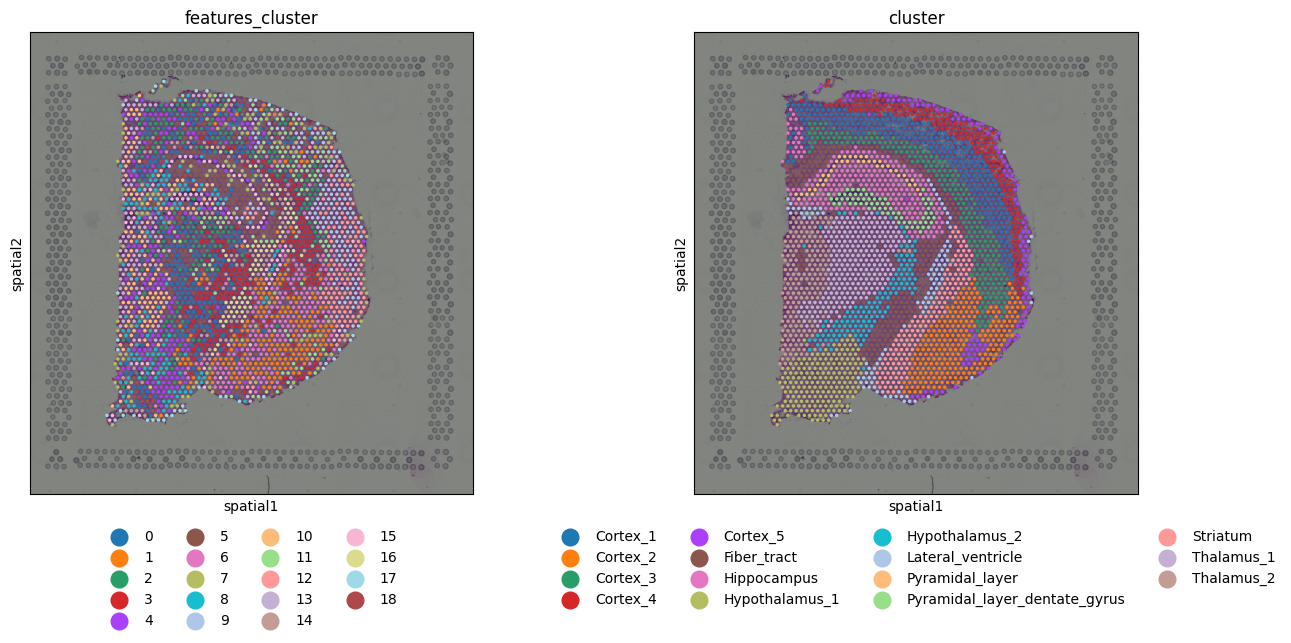

In [17]:
# compare feature and gene clusters
# sq.pl.spatial_scatter(adata, color=["features_cluster", "cluster"])

axs = sq.pl.spatial_scatter(
    adata,
    color=["features_cluster", "cluster"],
    return_ax=True,
)
axs = [axs] if not isinstance(axs, (list, tuple)) else axs

for ax in axs:
    leg = ax.get_legend()
    if leg is None:
        continue
    handles = leg.legend_handles          # .legendHandles on matplotlib < 3.7
    labels = [t.get_text() for t in leg.get_texts()]
    leg.remove()
    ax.legend(
        handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, -0.05),
        ncol=4, frameon=False, markerscale=2,
    )

Comparing gene and feature clusters, we notice that in some regions, they look very similar, like the cluster Fiber_tract, or clusters around the Hippocampus seems to be roughly recapitulated by the clusters in image feature space. In others, the feature clusters look different, like in the cortex, where the gene clusters show the layered structure of the cortex, and the features clusters rather seem to show different regions of the cortex.

This is only a simple, comparative analysis of the image features, note that you could also use the image features to e.g. compute a common image and gene clustering by computing a shared neighbors graph (for instance on concatenated PCAs on both feature spaces).

In [18]:
arr_spatial = adata.obsm['spatial']
arr_spatial

array([[8230, 7237],
       [4170, 1611],
       [2519, 8315],
       ...,
       [3276, 8435],
       [3069, 6639],
       [4720, 2090]], shape=(2688, 2))

In [19]:
dff = adata.obsm['features']
print(dff.shape)
dff.iloc[:3, :6]

(2688, 30)


,summary_ch-0_quantile-0.9,summary_ch-0_quantile-0.5,summary_ch-0_quantile-0.1,summary_ch-0_mean,summary_ch-0_std,summary_ch-1_quantile-0.9
AAACAAGTATCTCCCA-1,132.0,111.0,77.0,107.571140,21.767668,102.0
AAACAATCTACTAGCA-1,140.0,111.0,80.0,109.815175,25.047208,87.0
AAACACCAATAACTGC-1,132.0,116.0,89.0,112.421285,19.088559,109.0


### Save complete h5ad

In [20]:
filename = root_data / "visium_hne_complete.h5ad"
adata.write_h5ad(filename)

### Liana (Saez lab - Heidelberg)

https://github.com/saezlab/liana

### A. Cluster-level (non-spatial) LR inference

In [21]:
li.mt.rank_aggregate(
    adata,
    groupby="cluster",               # anatomical spot clusters (15 regions), not cell types
    resource_name="mouseconsensus",  # mouse gene symbols
    expr_prop=0.1,
    use_raw=False,                   # .raw holds counts here!
    n_perms=1000, n_jobs=8,
    verbose=True,
)


Using resource `mouseconsensus`.
Using `.X`!
/home/flavio/uv/squidpy/.venv/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.18 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 2688 samples and 1257 features


/home/flavio/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/flavio/uv/squidpy/.venv/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/home/flavio/uv/squidpy/.venv/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)
/home/flavio/uv/squidpy/.venv/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: The method uns_keys is deprecated and will be removed in the future. Use uns instead of uns_keys. (e.g. `k in adata.uns` or `sorted(adata.uns)`)


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:05<00:00, 187.65it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


### source, target, ligand_complex, receptor_complex, ...magnitude_rank, specificity_rank (lower = stronger)

In [22]:
res = adata.uns["liana_res"]
pdwritecsv(res, "liana_cluster_results.tsv", root_result, verbose=True)


Table saved ((190666, 13)) at '/home/flavio/uv/squidpy/results/liana_cluster_results.tsv'


True

In [23]:
top_specific = res[(res.specificity_rank <= 0.01)].sort_values("magnitude_rank")
pdwritecsv(top_specific, "liana_cluster_top_specific.tsv", root_result, verbose=True)

print(top_specific.shape)
top_specific.head(6)

Table saved ((25341, 13)) at '/home/flavio/uv/squidpy/results/liana_cluster_top_specific.tsv'
(25341, 13)


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
130723,Pyramidal_layer,Fiber_tract,App,Aplp1,3.613924,0.0,12.993496,1.206099,0.799214,0.006111,0.906885,0.001945,9.902685e-10
65802,Fiber_tract,Fiber_tract,App,Aplp1,3.563859,0.0,12.605726,1.088152,0.741875,0.005929,0.905598,0.003135,1.213058e-08
4024,Cortex_1,Fiber_tract,App,Aplp1,3.563744,0.0,12.604836,1.087882,0.726971,0.005928,0.905595,0.003553,1.584396e-08
29636,Cortex_3,Fiber_tract,App,Aplp1,3.553724,0.0,12.527227,1.064276,0.704703,0.005892,0.905330,0.004233,2.995468e-08
170893,Thalamus_1,Fiber_tract,App,Aplp1,3.532249,0.0,12.360901,1.013686,0.690519,0.005814,0.904756,0.004702,5.570007e-08
42170,Cortex_4,Fiber_tract,App,Aplp1,3.531248,0.0,12.353144,1.011327,0.668415,0.005810,0.904729,0.005650,6.337408e-08


### B. Spatially-resolved LR (per spot, no clusters needed)

- Spot centre spacing here is ~137 px (~100 um); bandwidth=200 px ~ 1-2 rings of neighbours.

In [25]:
li.ut.spatial_neighbors(adata, bandwidth=200, cutoff=0.1, kernel="gaussian", set_diag=True)

lrdata = li.mt.bivariate(
    adata, resource_name="mouseconsensus",
    local_name="cosine",     # local (per-spot) LR co-localisation score -> lrdata.X
    global_name="morans",    # global spatial autocorrelation per LR -> lrdata.var
    n_perms=100, mask_negatives=False, add_categories=True,
    nz_prop=0.2, use_raw=False, verbose=True,
)
# lrdata: spots x LR-pairs AnnData; .var has morans / morans_pvals; .layers['pvals'], ['cats']
top_global = lrdata.var.sort_values("morans", ascending=False)

Using `.X`!
Using resource `mouseconsensus`.
100%|██████████| 100/100 [00:04<00:00, 20.28it/s]


In [27]:
print(top_global.shape)
top_global.head(6)

(454, 10)


,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
Nptx1^Nptxr,Nptx1,Nptxr,1.045611,0.723586,1.783589,0.889509,0.434961,0.0,0.768262,0.197387
Rims1^Slc17a7,Rims1,Slc17a7,0.628196,0.638393,2.257496,0.891741,0.292247,0.0,0.708129,0.170169
Cck^Cckbr,Cck,Cckbr,2.622576,0.947917,0.295722,0.344494,0.243198,0.0,0.489883,0.263988
Sema4d^Plxnb3,Sema4d,Plxnb3,0.544131,0.524554,0.190867,0.219866,0.234733,0.0,0.385211,0.243879
Rtn4^Lingo1,Rtn4,Lingo1,2.446542,0.992188,1.553612,0.893601,0.217807,0.0,0.908484,0.081028
Rtn4^Rtn4r,Rtn4,Rtn4r,2.446542,0.992188,0.675537,0.588170,0.207650,0.0,0.719759,0.186195


### spatial (bivariate) results: the ligand\^receptor name is the INDEX, so keep it

In [28]:
pdwritecsv(lrdata.var.sort_values("morans", ascending=False),
           "liana_spatial_global_morans.tsv", root_result, index=True, verbose=True)

Table saved ((454, 10)) at '/home/flavio/uv/squidpy/results/liana_spatial_global_morans.tsv'


True

### Reading a file back

Tested sizes: the full table is 190,666 rows. The specificity_rank ≤ 0.01 filter keeps 25,341 rows, and the Moran's I table has 454 rows.



In [29]:
dfqq = pdreadcsv("liana_cluster_top_specific.tsv", root_result)
dfqq.shape

(25341, 13)

### Dotplot

In [32]:
p = li.pl.dotplot(adata=adata, colour="magnitude_rank", size="specificity_rank",
                  inverse_colour=True, inverse_size=True,
                  source_labels=["Hippocampus", "Pyramidal_layer", "Pyramidal_layer_dentate_gyrus"],
                  target_labels=["Cortex_1", "Thalamus_1", "Fiber_tract", "Hippocampus", "Striatum"],
                  filter_fun=lambda x: x["specificity_rank"] <= 0.01,
                  top_n=20, orderby="magnitude_rank", orderby_ascending=True, figure_size=(16, 10))

p.save(root_figure / "liana_cluster_dotplot.png", dpi=300, verbose=False)

/home/flavio/uv/squidpy/.venv/lib/python3.12/site-packages/liana/plotting/_common.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


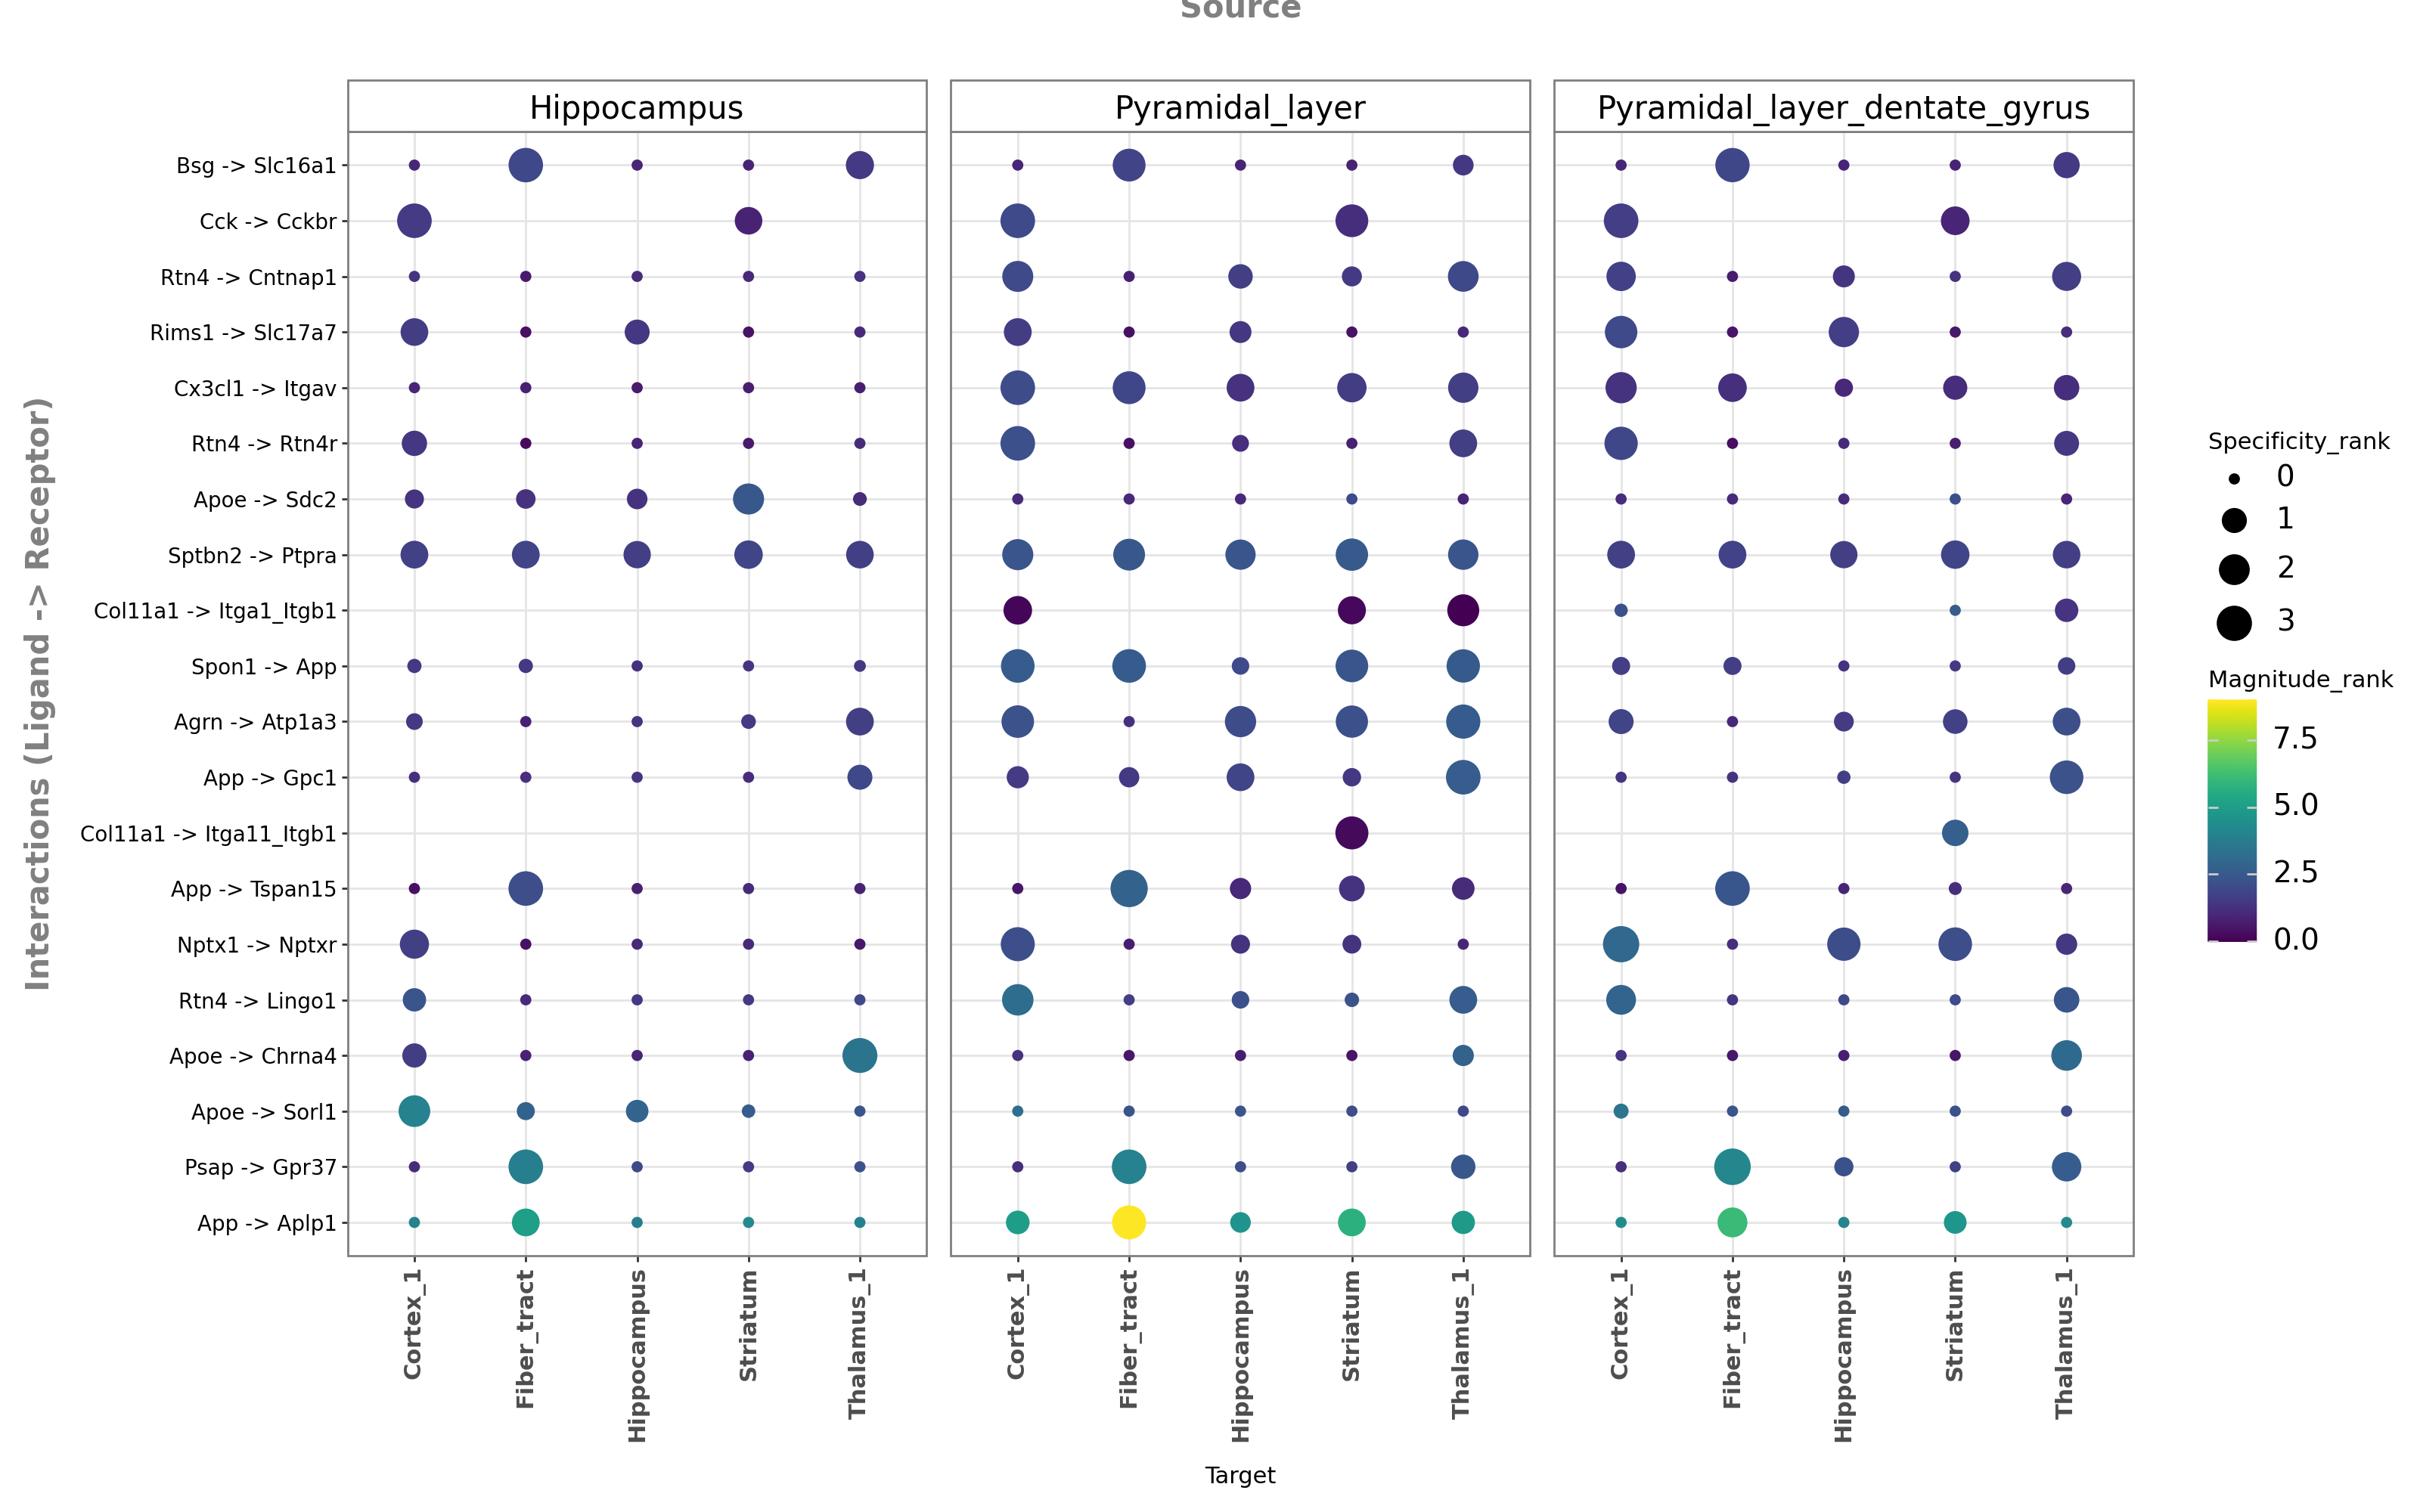

In [33]:
p.show()

### Squidpy and Scanpy plots. 

Get the axes back with return_ax=True, then save the parent figure:

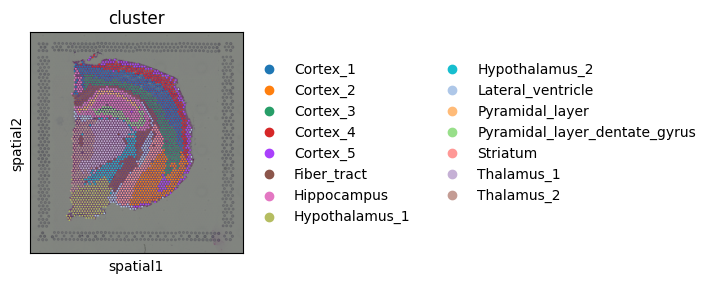

In [34]:
ax = sq.pl.spatial_scatter(adata, color="cluster", return_ax=True)
ax.figure.savefig(root_figure / "spatial_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

... storing 'ligand' as categorical
... storing 'receptor' as categorical


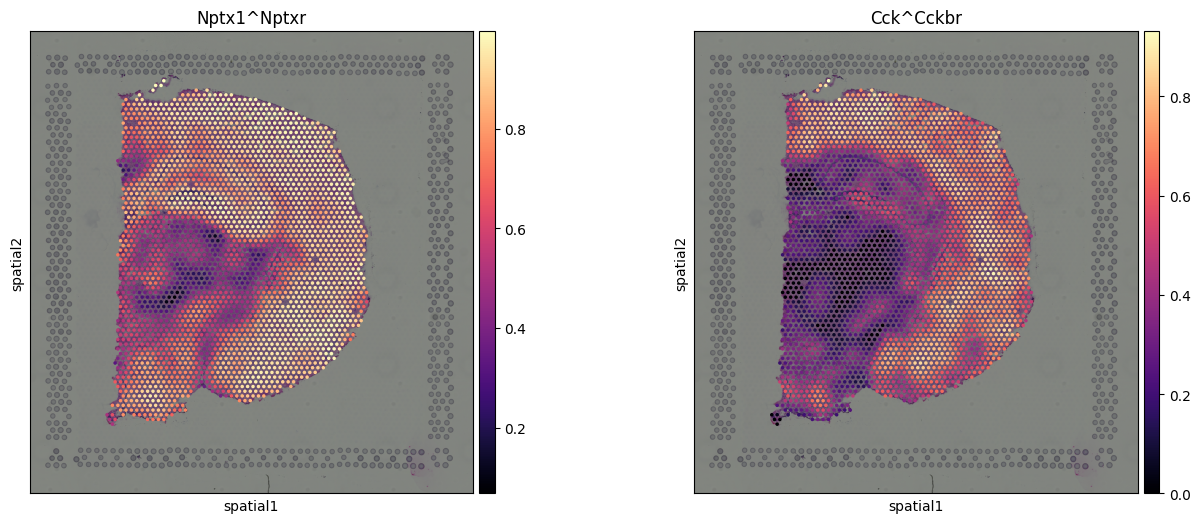

In [35]:
# several panels -> a list of axes; all share one figure
axs = sq.pl.spatial_scatter(lrdata, color=["Nptx1^Nptxr", "Cck^Cckbr"], cmap="magma", return_ax=True)
axs[0].figure.savefig(root_figure / "liana_spatial_LR.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
axs[0].figure.savefig(root_figure / "features_vs_gene_clusters.png", dpi=300, bbox_inches="tight")

![features_vs_gene_clusters](../figures/features_vs_gene_clusters.png)

### Plot: two things to watch for:

1. Save before plt.show(). In Jupyter, show() closes the figure, so saving afterwards writes a blank image.
2. bbox_inches="tight" matters. Without it, legends placed outside the axes, like the ones you move below the plot in cell 25, get cut off.


### Save spatial LIANA object

- That way you don't have to rerun li.mt.bivariate. 
- adata.uns["liana_res"] is already saved inside visium_hne_complete.h5ad if you write that file after running LIANA.


In [42]:
lrdata.write_h5ad(root_data / "visium_hne_liana_bivariate.h5ad")